Wrong pin. Enter again
Wrong pin. Enter again
Success you entered a correct pin in 3 attempts


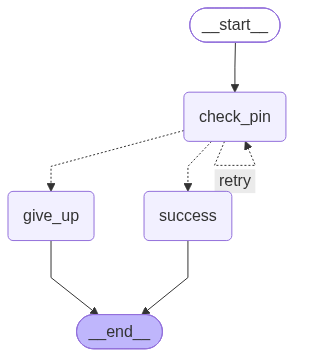

In [3]:
from typing import TypedDict,Literal
from langgraph.graph import StateGraph, START,END
from IPython.display import Image,display

class pinState(TypedDict):
    correct_pin : int
    entered_pin : int
    no_of_attempts : int
    max_attempts : int
    msg : str
    success : bool
    

def route_retry(state)-> Literal["success","retry","give_up"]:
    if(state["success"]):
        return "success"
    elif(state["no_of_attempts"]<= state["max_attempts"]):
        print(f"Wrong pin. Enter again")
        return "retry"
    else:
        return "give_up"
    

def success(state):
    msg = f"Success you entered a correct pin in {state["no_of_attempts"]} attempts"
    print(msg)
    return {
        "msg" : msg
    }
    
def give_up(state):
    msg = f"Failed you exceeded the {state["no_of_attempts"]} attempts"
    print(msg)
    return{
          "msg" : msg
        }
    
def check_pin(state):
    pin = int(input("Enter your pin: "))
    attempts = state["no_of_attempts"]+1
    if( pin == state["correct_pin"]):
        return {
            "entered_pin": pin,
            "no_of_attempts": attempts,
            "success": True
        }
    else:
        return {
            "entered_pin": pin,
            "no_of_attempts": attempts,
            "success": False
        }
        
builder = StateGraph(pinState)
builder.add_node("success",success)
builder.add_node("give_up",give_up)
builder.add_node("check_pin",check_pin)

builder.add_edge(START,"check_pin")
builder.add_conditional_edges(
    "check_pin",
    route_retry,
    {
        "success" : "success",
        "retry" : "check_pin",
        "give_up": "give_up" 
    }
)

builder.add_edge("success",END)
builder.add_edge("give_up",END)

graph = builder.compile()
result = graph.invoke({
    "correct_pin" : 1234,
    "entered_pin" : 0,
    "no_of_attempts" : 0,
    "max_attempts" : 3,
    "msg" : "",
    "success" : False
})
    
display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)


    